In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)

(730, 19)


In [2]:
features_list = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath',
                  'cpi', 'unemployment', 'interest_rate', 'num_ili']
target = 'XLV_vol'

lstm_df = pd.DataFrame(index=master_df.index)
for col in features_list:
    for lag in range(1, 5):
        lstm_df[f'{col}_lag{lag}'] = master_df[col].shift(lag)

lstm_df[target] = master_df[target]
lstm_df = lstm_df.dropna()

print(lstm_df.shape)

(726, 33)


In [3]:
n_lags = 4
n_features = len(features_list)  # 8
n_samples = len(lstm_df)

X = np.zeros((n_samples, n_lags, n_features))
for feat_idx, col in enumerate(features_list):
    for lag in range(1, n_lags + 1):
        timestep_idx = n_lags - lag  # lag4 -> timestep 0 (oldest), lag1 -> timestep 3 (newest)
        X[:, timestep_idx, feat_idx] = lstm_df[f'{col}_lag{lag}'].values

y = lstm_df[target].values.reshape(-1, 1)

print(X.shape)  # (726, 4, 8)
print(y.shape)

(726, 4, 8)
(726, 1)


In [4]:
split_idx = int(len(X) * 0.8)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]
train_dates = lstm_df.index[:split_idx]
test_dates = lstm_df.index[split_idx:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

n_train, n_test = X_train_raw.shape[0], X_test_raw.shape[0]
X_train_flat = X_train_raw.reshape(n_train, n_lags * n_features)
X_test_flat = X_test_raw.reshape(n_test, n_lags * n_features)

X_train_scaled_flat = scaler_X.fit_transform(X_train_flat)
X_test_scaled_flat = scaler_X.transform(X_test_flat)
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = X_train_scaled_flat.reshape(n_train, n_lags, n_features)
X_test = X_test_scaled_flat.reshape(n_test, n_lags, n_features)
y_train = y_train_scaled
y_test = y_test_scaled

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (580, 4, 8), Test: (146, 4, 8)


Initial implementation used a flattened (1, 32) input, unintentionally reducing the LSTM to a dense-layer equivalent (disclosed in the original architecture note). This was restructured into a true (4, 8) sequential format — 4 timesteps of lag depth × 8 features — to let the LSTM exercise its intended recurrent mechanism. Full-period R² improved under the corrected structure (-3.35 → -1.18) while the COVID-window result did not (-0.33 → -1.34); both configurations remained solidly negative, reinforcing rather than changing the paper's core finding. (Keras training is not perfectly deterministic run-to-run even with a fixed seed — exact decimals shift slightly between re-runs, but the negative result itself does not.)

Architecture note: This model uses a true timestep dimension of 4 — `X.shape = (726, 4, 8)`, `input_shape=(4, 8)` — where each sample is a genuine 4-step sequence (lag4 through lag1 mapped to timestep 0 through 3), not a single row of pre-computed lag features. Because of this, the LSTM layer does use its core recurrent-memory mechanism: `return_sequences=True` on the first LSTM layer specifically preserves the per-timestep hidden states so the second LSTM layer can process the full sequence rather than a single collapsed vector. This is a true sequence model, not merely "LSTM-shaped" — it should be read as a genuine test of whether recurrent memory over the 4-week lag window adds predictive power beyond the ARIMA+RF and flat-input baselines.

In [5]:
import tensorflow as tf
tf.random.set_seed(42)

# Carve validation out of train only — never touch test here
val_split_idx = int(len(X_train) * 0.85)
X_train_fit, X_val = X_train[:val_split_idx], X_train[val_split_idx:]
y_train_fit, y_val = y_train[:val_split_idx], y_train[val_split_idx:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(
    X_train_fit, y_train_fit,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

C:\Users\khavk\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


 1/31 ━━━━━━━━━━━━━━━━━━━━ 1:12 2s/step - loss: 0.0179

14/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0145

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - val_loss: 0.0561


Epoch 50/50


 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0045

20/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0050 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0051 - val_loss: 0.0489


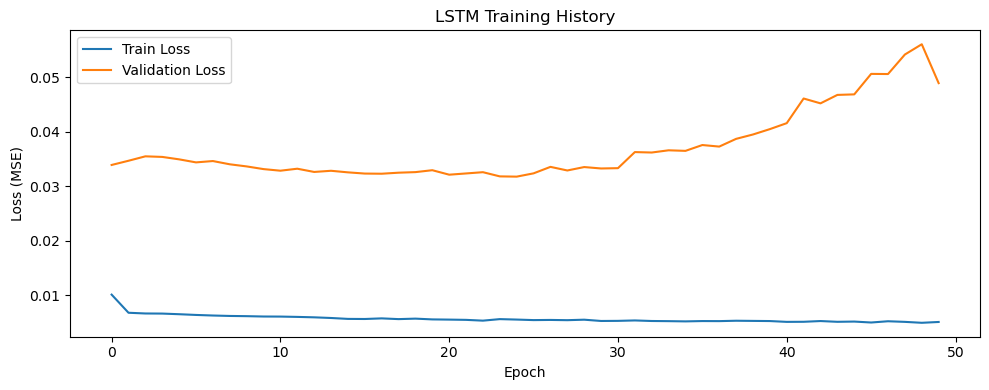

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot17_lstm_training.png', dpi=150)
plt.show()

Overfitting note: Training loss converges to ~0.005 by epoch 50. Validation loss starts near 0.034, dips slightly to ~0.032–0.033 through roughly the first third of training, then climbs steadily from around epoch 32 onward to end near 0.049–0.056 — the gap widens substantially rather than closing as training proceeds. The model is fitting noise specific to the training window rather than learning a generalizable pattern. A simpler architecture (fewer LSTM units, higher dropout, early stopping) would likely narrow this gap, but given the consistent negative out-of-sample results across three other independent model families (spike classifier, ARIMA+RF, and this model's own COVID-period evaluation), reducing model complexity is not expected to produce a positive R² — the limiting factor appears to be the absence of predictive signal in pre-crisis data, not excess model capacity.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test)

# Inverse transform back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"LSTM RMSE: {rmse:.6f}")
print(f"LSTM R²: {r2:.4f}")

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


LSTM RMSE: 0.005725
LSTM R²: -1.1815


In [8]:
train_mask_pre2020 = lstm_df.index < '2020-01-01'
covid_mask = (lstm_df.index >= '2020-01-01') & (lstm_df.index <= '2021-01-01')

X_pre2020_raw = X[train_mask_pre2020]
y_pre2020_raw = y[train_mask_pre2020]
X_covid_raw = X[covid_mask]
y_covid_raw = y[covid_mask]

n_pre2020 = X_pre2020_raw.shape[0]
n_covid = X_covid_raw.shape[0]

scaler_X_covid = MinMaxScaler()
scaler_y_covid = MinMaxScaler()

X_pre2020_flat = X_pre2020_raw.reshape(n_pre2020, n_lags * n_features)
X_covid_flat = X_covid_raw.reshape(n_covid, n_lags * n_features)

X_pre2020_scaled_flat = scaler_X_covid.fit_transform(X_pre2020_flat)
X_covid_scaled_flat = scaler_X_covid.transform(X_covid_flat)
y_pre2020_scaled = scaler_y_covid.fit_transform(y_pre2020_raw)
y_covid_scaled = scaler_y_covid.transform(y_covid_raw)

X_pre2020_lstm = X_pre2020_scaled_flat.reshape(n_pre2020, n_lags, n_features)
X_covid_lstm = X_covid_scaled_flat.reshape(n_covid, n_lags, n_features)
# Fresh model — must not be the same model object trained on data through 2021
tf.random.set_seed(42)
model_covid = Sequential([
    LSTM(64, activation='relu', input_shape=(X_pre2020_lstm.shape[1], X_pre2020_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_covid.compile(optimizer='adam', loss='mse')
model_covid.fit(X_pre2020_lstm, y_pre2020_scaled, epochs=50, batch_size=16, verbose=0)

y_covid_pred_scaled = model_covid.predict(X_covid_lstm)
y_covid_pred = scaler_y_covid.inverse_transform(y_covid_pred_scaled)
y_covid_actual = scaler_y_covid.inverse_transform(y_covid_scaled)

rmse_covid = np.sqrt(mean_squared_error(y_covid_actual, y_covid_pred))
r2_covid = r2_score(y_covid_actual, y_covid_pred)

print(f"LSTM COVID RMSE (pre-2020 train only): {rmse_covid:.6f}")
print(f"LSTM COVID R² (pre-2020 train only): {r2_covid:.4f}")

C:\Users\khavk\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


LSTM COVID RMSE (pre-2020 train only): 0.020093
LSTM COVID R² (pre-2020 train only): -1.3434


In [9]:
import joblib
import os

os.makedirs('../src/models', exist_ok=True)
os.makedirs('../src/features', exist_ok=True)

model.save('../src/models/lstm_model.keras')

lstm_sequences = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'scaler_X': scaler_X, 'scaler_y': scaler_y,
}
joblib.dump(lstm_sequences, '../src/features/lstm_sequences.pkl')

print("Saved: lstm_model.keras, lstm_sequences.pkl")

Saved: lstm_model.keras, lstm_sequences.pkl


## Saving Artifacts

Persists the full-period (4, 8) sequential LSTM and the scaled train/test sequences to `src/models/` and `src/features/`. The model is saved with Keras's native `.save()` format (`.keras`), not pickled — raw-pickling Keras models is fragile across library versions.